# Personal Gym Supplements RAG

Same RAGWire pipeline as Module 2 — different domain, different data, different system prompt.
This shows how little needs to change to go from finance to health.

**Chat model:** selected explicitly as `free` or `paid` through RAGWire (OpenRouter) · **Embedding:** local `BAAI/bge-m3` · **Vector Store:** Qdrant

The free NVIDIA endpoint may log prompts, so use public or non-sensitive documents only. Selecting `paid` is explicit and requires OpenRouter credit; it can create billable requests.

## 1. Setup and Ingest

In [1]:
import sys
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(override=True)

# Prefer the canonical package when this notebook is launched from Lesson 04.
REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "PLANS.md").exists() and (path / "ragwire/__init__.py").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from ragwire import RAGWire, setup_logging
import ragwire

MODEL_TIER = "free"  # change explicitly to "paid" when desired
CONFIG_PATH = "config_openrouter_qdrant.yaml"

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)
print("Free-tier prompts may be logged; use public/non-sensitive documents only.")


1.2.9
Free-tier prompts may be logged; use public/non-sensitive documents only.


In [2]:
rag = RAGWire(CONFIG_PATH, model_tier=MODEL_TIER)
print(f"Using {rag.model_tier} model: {rag.config['llm']['model']}")

2026-08-31 04:16:36,734 - ragwire.core.pipeline - INFO - Loading configuration from config_openrouter_qdrant.yaml
2026-08-31 04:16:36,738 - ragwire.core.pipeline - INFO - Selected free LLM model: nvidia/nemotron-3-super-120b-a12b:free
2026-08-31 04:16:36,878 - ragwire.core.pipeline - INFO - Document loader initialized
2026-08-31 04:16:36,878 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-08-31 04:16:37,066 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=fastembed)
2026-08-31 04:16:37,775 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: health_metadata.yaml
2026-08-31 04:16:37,775 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=openrouter, model=nvidia/nemotron-3-super-120b-a12b:free)
2026-08-31 04:16:38,106 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333 (timeout=300s)
2026-08-31 04:16:38,195 - ragwire.vectorstores.qd

In [3]:
rag.ingest_directory('../data/health_data')

2026-08-31 04:16:42,958 - ragwire.core.pipeline - INFO - Found 10 file(s) in ../data/health_data
2026-08-31 04:16:42,959 - ragwire.core.pipeline - INFO - Starting ingestion of 10 documents


Ingesting:   0%|          | 0/10 [00:00<?, ?file/s]

2026-08-31 04:17:21,524 - ragwire.core.pipeline - INFO - Processed ../data/health_data/06_Caffeine_Beta-Alanine_2024.pdf: 11 chunks


Ingesting:  10%|█         | 1/10 [00:38<05:46, 38.54s/file]

2026-08-31 04:17:58,888 - ragwire.core.pipeline - INFO - Processed ../data/health_data/10_Functional_Foods_Athletes_2025.pdf: 7 chunks


...

Ingesting:  90%|█████████ | 9/10 [06:46<00:44, 44.66s/file]

2026-08-31 04:23:49,190 - ragwire.core.pipeline - INFO - Processed ../data/health_data/04_Supplement_Health_2024.pdf: 3 chunks


Ingesting: 100%|██████████| 10/10 [07:06<00:00, 42.62s/file]


2026-08-31 04:23:49,710 - ragwire.core.pipeline - INFO - Ingestion complete: 9/10 documents


{'total': 10,
 'processed': 9,
 'skipped': 1,
 'failed': 0,
 'chunks_created': 75,
 'errors': []}

## 2. Basic Retrieval

In [4]:
rag.retrieve("protein", top_k=3)

2026-08-31 04:35:30,878 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: protein...


[Document(metadata={'source': '../data/health_data/01_Elite_Athletes_Supplements_2025.pdf', 'file_name': '01_Elite_Athletes_Supplements_2025.pdf', 'file_type': 'pdf', 'file_hash': 'd2ee08e35b3a73da4e47f6d4691020ed2aab815ef5dca2b370ea25d11bb20497', 'chunk_id': 'd2ee08e35b3a73da4e47f6d4691020ed2aab815ef5dca2b370ea25d11bb20497_13', 'chunk_hash': 'b08f42d6bc69e4c1e2815e7c3f28c540e54bc6f5e7e919a4e1354ded026c2458', 'chunk_index': 13, 'total_chunks': 26, 'created_at': '2026-08-30T22:22:42.914968+00:00', 'title': 'efficacy of dietary supplements on sports performance', 'authors': ['ellenglickman', 'oghrenumeemakpor', 'coreypeacock', 'tongwuyu', 'chuanweiding'], 'publication_year': 2025, 'research_focus': ['dietary-supplements', 'sports-performance', 'elite-athletes', 'supplement-type', 'dosing-protocols', 'sport-specific-demands', 'caffeine', 'beta-alanine', 'nitrate-supplementation', 'recovery-supplements', 'amino-acids', 'probiotics', 'fatigue-prevention', 'exercise-tolerance'], '_id': '983a

In [5]:
rag.retrieve("what are the benefits of vitamin d?", top_k=3)

2026-08-31 04:35:39,254 - ragwire.core.pipeline - INFO - Retrieved 3 documents for query: what are the benefits of vitamin d?...


[Document(metadata={'source': '../data/health_data/03_Vitamin_D_Performance_2024.pdf', 'file_name': '03_Vitamin_D_Performance_2024.pdf', 'file_type': 'pdf', 'file_hash': '99802bd81e27a7cde5508eeedaad515bac3bb16c6e12b63e94219fd9cd5b59ae', 'chunk_id': '99802bd81e27a7cde5508eeedaad515bac3bb16c6e12b63e94219fd9cd5b59ae_0', 'chunk_hash': 'f786804941b1419d967dbede58b18de0422a44e36d71986d814d8ab6ae8c9f7a', 'chunk_index': 0, 'total_chunks': 7, 'created_at': '2026-08-30T22:18:47.264455+00:00', 'title': 'effect of vitamin d on athletic performance: a systematic review', 'authors': ['nader maai', 'florian a. frank', 'arthur meuris', 'nando ferreira'], 'publication_year': 2025, 'research_focus': ['vitamin-d', 'athletic-performance', 'supplementation', 'serum-25-ohd-levels', 'haematological-recovery', 'muscle-recovery', 'seasonal-fluctuations', 'vitamin-d-status', 'individual-characteristics', 'type-of-exercise', 'dosage', 'duration'], '_id': '663d8956-b0d8-432f-a884-18398281d593', '_collection_name

## 3. Agent

Same two tools from Module 2 (`get_filter_context`, `search_documents`).
The only difference: the system prompt is tuned for a health and fitness assistant.

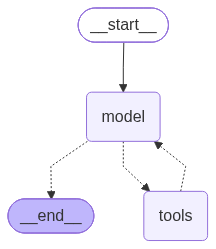

In [7]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves retrieving a title,
    authors, publication_year, or research_focus. Skip for purely semantic queries.
    """
    return rag.get_filter_context(query)

@tool
def search_documents(query: str, filters=None):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context.
    """

    results = rag.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results

agent = create_agent(
    model=rag.llm,
    tools=[get_filter_context, search_documents],
    system_prompt="""You are a helpful health and fitness assistant.
                    For complex questions, break them down into simple sub-questions.
                    Always use search_documents to retrieve information — never answer from general knowledge.
                    Use get_filter_context before search_documents when the query involves specific metadata.
                    Always cite the source document in your answer.""",

    checkpointer=InMemorySaver(),
)

agent


## 4. Interactive Q&A

In [8]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.

2026-08-31 04:39:08,537 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: vitamin C benefits...

Agent: Based on the retrieved document, vitamin C (ascorbic acid) provides several key benefits for health and athletic performance:

- **Supports wound healing** – it is essential for the repair of damaged tissue.  
- **Promotes collagen production** – vitamin C acts as a cofactor that stabilizes collagen structure and enhances collagen gene expression in fibroblasts, which is crucial for maintaining the strength and integrity of joints, muscles, and connective tissue.  
- **Contributes to tissue repair and recovery** – by boosting collagen synthesis, vitamin C aids in the recovery of muscles and joints after exercise or injury.  

These benefits are highlighted in the section on vitamin C within the nutrition and hydration strategies for athletic performance document【0†L1-L9】.

